In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = '../data/Snake Images'
img_size = (224, 224)   # MobileNetV2's expected input size
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{data_dir}/train', target_size=img_size, batch_size=batch_size,
    class_mode='binary', subset='training'
)
val_gen = train_datagen.flow_from_directory(
    f'{data_dir}/train', target_size=img_size, batch_size=batch_size,
    class_mode='binary', subset='validation'
)
test_gen = test_datagen.flow_from_directory(
    f'{data_dir}/test', target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=False
)

labels = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))
print(class_weights)

Found 1420 images belonging to 2 classes.
Found 355 images belonging to 2 classes.
Found 269 images belonging to 2 classes.
{0: 1.2412587412587412, 1: 0.8372641509433962}


In [3]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze pretrained layers first

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()



9406464/9406464 [==============================] - 1s 0us/step

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                        

In [4]:
history1 = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8


45/45 [==============================] - 123s 2s/step - loss: 0.6467 - accuracy: 0.6493 - val_loss: 0.5548 - val_accuracy: 0.7127
Epoch 2/8
45/45 [==============================] - 47s 1s/step - loss: 0.4582 - accuracy: 0.7803 - val_loss: 0.4720 - val_accuracy: 0.7972
Epoch 3/8
45/45 [==============================] - 45s 999ms/step - loss: 0.4189 - accuracy: 0.8099 - val_loss: 0.4326 - val_accuracy: 0.8085
Epoch 4/8
45/45 [==============================] - 45s 996ms/step - loss: 0.3822 - accuracy: 0.8310 - val_loss: 0.4443 - val_accuracy: 0.7944
Epoch 5/8
45/45 [==============================] - 46s 1s/step - loss: 0.3551 - accuracy: 0.8493 - val_loss: 0.4533 - val_accuracy: 0.8056
Epoch 6/8
45/45 [==============================] - 46s 1s/step - loss: 0.3451 - accuracy: 0.8444 - val_loss: 0.3742 - val_accuracy: 0.8169
Epoch 7/8
45/45 [==============================] - 47s 1s/step - loss: 0.3422 - accuracy: 0.8493 - val_loss: 0.4479 - val_accuracy: 0.8056
Epoch 8/8
45/45 [=

In [5]:
base_model.trainable = True
# freeze all but the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
45/45 [==============================] - 61s 1s/step - loss: 0.4209 - accuracy: 0.8141 - val_loss: 0.4044 - val_accuracy: 0.8310
Epoch 2/5
45/45 [==============================] - 47s 1s/step - loss: 0.3556 - accuracy: 0.8338 - val_loss: 0.3942 - val_accuracy: 0.8056
Epoch 3/5
45/45 [==============================] - 49s 1s/step - loss: 0.3497 - accuracy: 0.8437 - val_loss: 0.4297 - val_accuracy: 0.8056
Epoch 4/5
45/45 [==============================] - 47s 1s/step - loss: 0.3274 - accuracy: 0.8542 - val_loss: 0.3921 - val_accuracy: 0.8225
Epoch 5/5
45/45 [==============================] - 46s 1s/step - loss: 0.3437 - accuracy: 0.8486 - val_loss: 0.4184 - val_accuracy: 0.8338


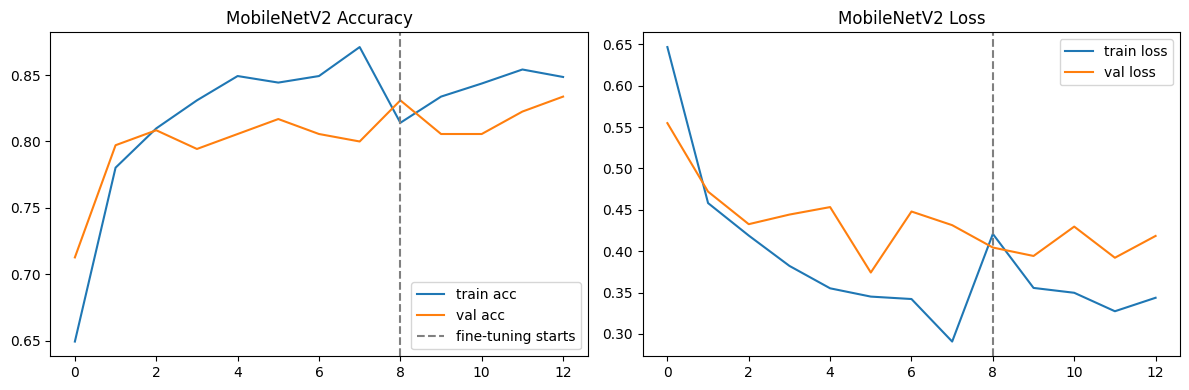

In [6]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.axvline(x=len(history1.history['accuracy']), color='gray', linestyle='--', label='fine-tuning starts')
plt.title('MobileNetV2 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.axvline(x=len(history1.history['loss']), color='gray', linestyle='--')
plt.title('MobileNetV2 Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../notebooks/mobilenet_training_curves.png', dpi=150)
plt.show()

In [7]:
test_gen.reset()
preds = mobilenet_model.predict(test_gen)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen.classes

print(classification_report(true_labels, pred_labels, target_names=list(test_gen.class_indices.keys())))
print(confusion_matrix(true_labels, pred_labels))

9/9 [==============================] - 4s 251ms/step
              precision    recall  f1-score   support

Non Venomous       0.83      0.79      0.81       128
    Venomous       0.82      0.86      0.84       141

    accuracy                           0.83       269
   macro avg       0.83      0.82      0.82       269
weighted avg       0.83      0.83      0.82       269

[[101  27]
 [ 20 121]]


In [8]:
mobilenet_model.save('../models/mobilenet_v2.h5')

C:\Users\inshaaf\anaconda3\envs\snake-classifier\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [9]:
from tensorflow.keras.applications import EfficientNetB0

In [10]:
base_model2 = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model2.trainable = False

efficientnet_model = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

efficientnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

16705208/16705208 [==============================] - 3s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                       

In [11]:
history3 = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
45/45 [==============================] - 64s 1s/step - loss: 0.7203 - accuracy: 0.4810 - val_loss: 0.6810 - val_accuracy: 0.5972
Epoch 2/8
45/45 [==============================] - 47s 1s/step - loss: 0.6951 - accuracy: 0.5239 - val_loss: 0.6908 - val_accuracy: 0.5972
Epoch 3/8
45/45 [==============================] - 48s 1s/step - loss: 0.6945 - accuracy: 0.4697 - val_loss: 0.6947 - val_accuracy: 0.4028
Epoch 4/8
45/45 [==============================] - 48s 1s/step - loss: 0.6935 - accuracy: 0.4211 - val_loss: 0.6936 - val_accuracy: 0.4028
Epoch 5/8
45/45 [==============================] - 47s 1s/step - loss: 0.6932 - accuracy: 0.5838 - val_loss: 0.6931 - val_accuracy: 0.5972
Epoch 6/8
45/45 [==============================] - 46s 1s/step - loss: 0.6932 - accuracy: 0.4232 - val_loss: 0.6931 - val_accuracy: 0.5972
Epoch 7/8
45/45 [==============================] - 49s 1s/step - loss: 0.6932 - accuracy: 0.5972 - val_loss: 0.6930 - val_accuracy: 0.5972
Epoch 8/8
45/45 [==========

In [12]:
base_model2.trainable = True
for layer in base_model2.layers[:-30]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history4 = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
45/45 [==============================] - 68s 1s/step - loss: 0.7383 - accuracy: 0.5648 - val_loss: 0.6928 - val_accuracy: 0.5972
Epoch 2/5
45/45 [==============================] - 50s 1s/step - loss: 0.7221 - accuracy: 0.5275 - val_loss: 0.6928 - val_accuracy: 0.5972
Epoch 3/5
45/45 [==============================] - 50s 1s/step - loss: 0.7127 - accuracy: 0.5106 - val_loss: 0.6928 - val_accuracy: 0.5972
Epoch 4/5
45/45 [==============================] - 52s 1s/step - loss: 0.7083 - accuracy: 0.4915 - val_loss: 0.6921 - val_accuracy: 0.5972
Epoch 5/5
45/45 [==============================] - 51s 1s/step - loss: 0.7091 - accuracy: 0.4937 - val_loss: 0.6911 - val_accuracy: 0.5972


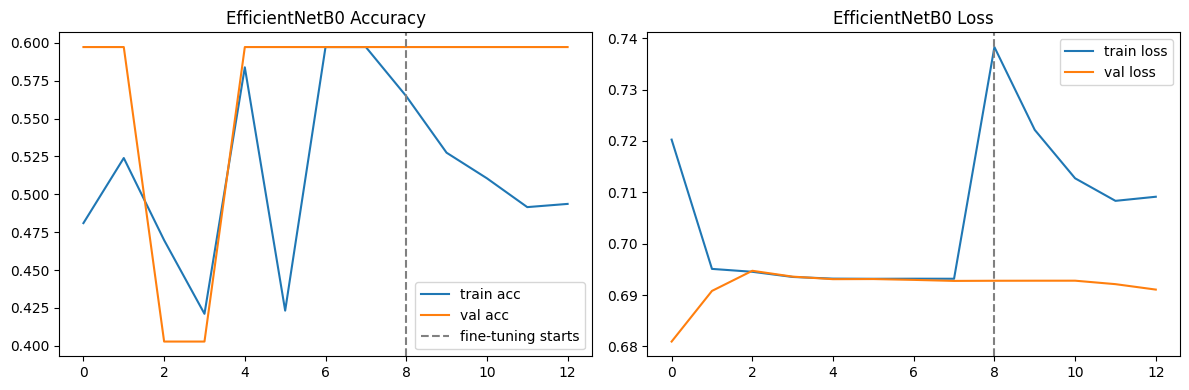

In [13]:
acc = history3.history['accuracy'] + history4.history['accuracy']
val_acc = history3.history['val_accuracy'] + history4.history['val_accuracy']
loss = history3.history['loss'] + history4.history['loss']
val_loss = history3.history['val_loss'] + history4.history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.axvline(x=len(history3.history['accuracy']), color='gray', linestyle='--', label='fine-tuning starts')
plt.title('EfficientNetB0 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.axvline(x=len(history3.history['loss']), color='gray', linestyle='--')
plt.title('EfficientNetB0 Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../notebooks/efficientnet_training_curves.png', dpi=150)
plt.show()

In [14]:
efficientnet_model.save('../models/efficientnet_b0.h5')

In [25]:
train_datagen_eff = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
    # NOTE: no rescale=1./255 here — EfficientNetB0 handles that internally
)
test_datagen_eff = ImageDataGenerator()  # no rescale here either

train_gen_eff = train_datagen_eff.flow_from_directory(
    f'{data_dir}/train', target_size=img_size, batch_size=batch_size,
    class_mode='binary', subset='training'
)
val_gen_eff = train_datagen_eff.flow_from_directory(
    f'{data_dir}/train', target_size=img_size, batch_size=batch_size,
    class_mode='binary', subset='validation'
)
test_gen_eff = test_datagen_eff.flow_from_directory(
    f'{data_dir}/test', target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=False
)

Found 1420 images belonging to 2 classes.
Found 355 images belonging to 2 classes.
Found 269 images belonging to 2 classes.


In [26]:
base_model2 = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model2.trainable = False

efficientnet_model = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

efficientnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_4  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               163968    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 4213668 (16.07 MB)
Trainable params: 164

In [18]:
history3 = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
45/45 [==============================] - 131s 2s/step - loss: 0.5207 - accuracy: 0.7218 - val_loss: 0.4099 - val_accuracy: 0.8000
Epoch 2/8
45/45 [==============================] - 94s 2s/step - loss: 0.3763 - accuracy: 0.8324 - val_loss: 0.3889 - val_accuracy: 0.8085
Epoch 3/8
45/45 [==============================] - 99s 2s/step - loss: 0.3099 - accuracy: 0.8570 - val_loss: 0.3563 - val_accuracy: 0.8254
Epoch 4/8
45/45 [==============================] - 99s 2s/step - loss: 0.2739 - accuracy: 0.8803 - val_loss: 0.3114 - val_accuracy: 0.8535
Epoch 5/8
45/45 [==============================] - 97s 2s/step - loss: 0.2646 - accuracy: 0.8873 - val_loss: 0.3321 - val_accuracy: 0.8676
Epoch 6/8
45/45 [==============================] - 97s 2s/step - loss: 0.2397 - accuracy: 0.8965 - val_loss: 0.3063 - val_accuracy: 0.8648
Epoch 7/8
45/45 [==============================] - 97s 2s/step - loss: 0.2131 - accuracy: 0.9162 - val_loss: 0.3052 - val_accuracy: 0.8789
Epoch 8/8
45/45 [=========

In [19]:
base_model2.trainable = True
for layer in base_model2.layers[:-30]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history4 = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
45/45 [==============================] - 138s 2s/step - loss: 0.3691 - accuracy: 0.8352 - val_loss: 0.3141 - val_accuracy: 0.8676
Epoch 2/5
45/45 [==============================] - 94s 2s/step - loss: 0.3251 - accuracy: 0.8592 - val_loss: 0.3349 - val_accuracy: 0.8676
Epoch 3/5
45/45 [==============================] - 98s 2s/step - loss: 0.3128 - accuracy: 0.8613 - val_loss: 0.3827 - val_accuracy: 0.8225
Epoch 4/5
45/45 [==============================] - 98s 2s/step - loss: 0.3202 - accuracy: 0.8641 - val_loss: 0.3586 - val_accuracy: 0.8423
Epoch 5/5
45/45 [==============================] - 99s 2s/step - loss: 0.2852 - accuracy: 0.8852 - val_loss: 0.3508 - val_accuracy: 0.8451


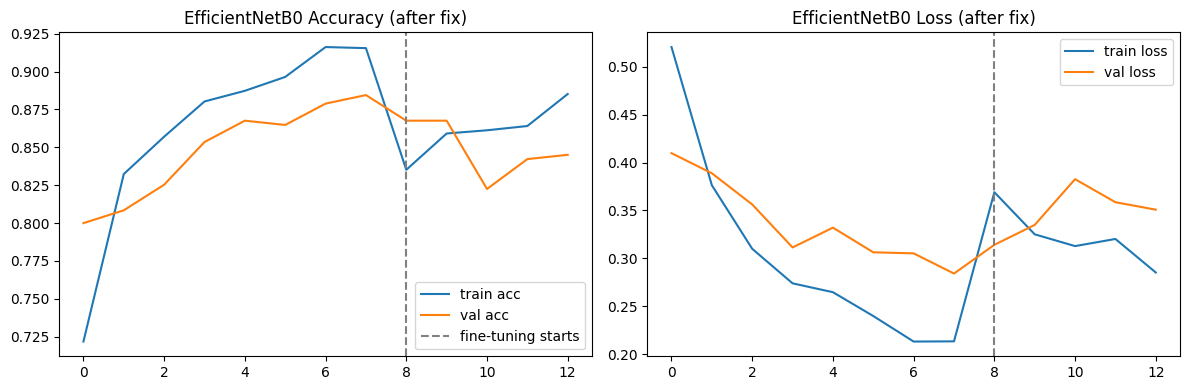

In [27]:
acc = history3.history['accuracy'] + history4.history['accuracy']
val_acc = history3.history['val_accuracy'] + history4.history['val_accuracy']
loss = history3.history['loss'] + history4.history['loss']
val_loss = history3.history['val_loss'] + history4.history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.axvline(x=len(history3.history['accuracy']), color='gray', linestyle='--', label='fine-tuning starts')
plt.title('EfficientNetB0 Accuracy (after fix)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.axvline(x=len(history3.history['loss']), color='gray', linestyle='--')
plt.title('EfficientNetB0 Loss (after fix)')
plt.legend()

plt.tight_layout()
plt.savefig('../notebooks/efficientnet_fixed_training_curves.png', dpi=150)
plt.show()

In [20]:
test_gen_eff.reset()
preds = efficientnet_model.predict(test_gen_eff)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen_eff.classes

print(classification_report(true_labels, pred_labels, target_names=list(test_gen_eff.class_indices.keys())))
print(confusion_matrix(true_labels, pred_labels))

9/9 [==============================] - 12s 651ms/step
              precision    recall  f1-score   support

Non Venomous       0.84      0.89      0.87       128
    Venomous       0.90      0.85      0.87       141

    accuracy                           0.87       269
   macro avg       0.87      0.87      0.87       269
weighted avg       0.87      0.87      0.87       269

[[114  14]
 [ 21 120]]


In [21]:
efficientnet_model.save('../models/efficientnet_b0.h5')

C:\Users\inshaaf\anaconda3\envs\snake-classifier\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [22]:
test_gen.reset()
preds = mobilenet_model.predict(test_gen)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen.classes

print(classification_report(true_labels, pred_labels, target_names=list(test_gen.class_indices.keys())))
print(confusion_matrix(true_labels, pred_labels))

9/9 [==============================] - 4s 392ms/step
              precision    recall  f1-score   support

Non Venomous       0.83      0.79      0.81       128
    Venomous       0.82      0.86      0.84       141

    accuracy                           0.83       269
   macro avg       0.83      0.82      0.82       269
weighted avg       0.83      0.83      0.82       269

[[101  27]
 [ 20 121]]


In [23]:
efficientnet_model.save('../models/efficientnet_b0.keras')

In [24]:
import tensorflow as tf
tf.saved_model.save(efficientnet_model, '../models/efficientnet_savedmodel')

INFO:tensorflow:Assets written to: ../models/efficientnet_savedmodel\assets


INFO:tensorflow:Assets written to: ../models/efficientnet_savedmodel\assets
